# Классификация ирисов (Iris)

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import confusion_matrix

from nn_framework import *
from nn_framework.evolution import *

%matplotlib inline

In [2]:
iris = load_iris()
X, y = iris.data, iris.target.reshape(-1, 1)

encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

In [3]:
train_ds = Dataset(X_train, y_train)
train_loader = DataLoader(train_ds, batch_size=16)
test_loader = DataLoader(Dataset(X_test, y_test), batch_size=16, shuffle=False)

In [4]:
model_net = Sequential(
    Linear(4, 16),
    ReLU(),
    Linear(16, 3),
    Softmax()
)

model = Model(
    network=model_net,
    loss_fn=CrossEntropy(),
    optimizer=Adam(model_net.parameters(), lr=0.01),
    metrics=[Accuracy()]
)

In [5]:
print("Обучение на Iris: ")
model.fit(train_loader, epochs=25)

Обучение на Iris: 
Epoch [1/25] - loss: 1.2175 - accuracy: 0.4917 - 0.01s
Epoch [2/25] - loss: 0.8230 - accuracy: 0.6250 - 0.01s
Epoch [3/25] - loss: 0.6048 - accuracy: 0.7583 - 0.01s
Epoch [4/25] - loss: 0.4824 - accuracy: 0.8167 - 0.00s
Epoch [5/25] - loss: 0.4187 - accuracy: 0.8250 - 0.00s
Epoch [6/25] - loss: 0.3767 - accuracy: 0.8417 - 0.00s
Epoch [7/25] - loss: 0.3365 - accuracy: 0.8750 - 0.01s
Epoch [8/25] - loss: 0.3049 - accuracy: 0.8667 - 0.00s
Epoch [9/25] - loss: 0.2866 - accuracy: 0.8833 - 0.00s
Epoch [10/25] - loss: 0.2680 - accuracy: 0.9083 - 0.01s
Epoch [11/25] - loss: 0.2445 - accuracy: 0.9167 - 0.01s
Epoch [12/25] - loss: 0.2187 - accuracy: 0.9250 - 0.01s
Epoch [13/25] - loss: 0.1975 - accuracy: 0.9417 - 0.01s
Epoch [14/25] - loss: 0.1890 - accuracy: 0.9417 - 0.01s
Epoch [15/25] - loss: 0.1677 - accuracy: 0.9750 - 0.01s
Epoch [16/25] - loss: 0.1591 - accuracy: 0.9500 - 0.01s
Epoch [17/25] - loss: 0.1509 - accuracy: 0.9583 - 0.00s
Epoch [18/25] - loss: 0.1397 - accurac

In [6]:
print("\nРезультаты на тестовой выборке:")
results = model.evaluate(test_loader)
print(results)


Результаты на тестовой выборке:
{'accuracy': np.float64(0.9666666666666667)}


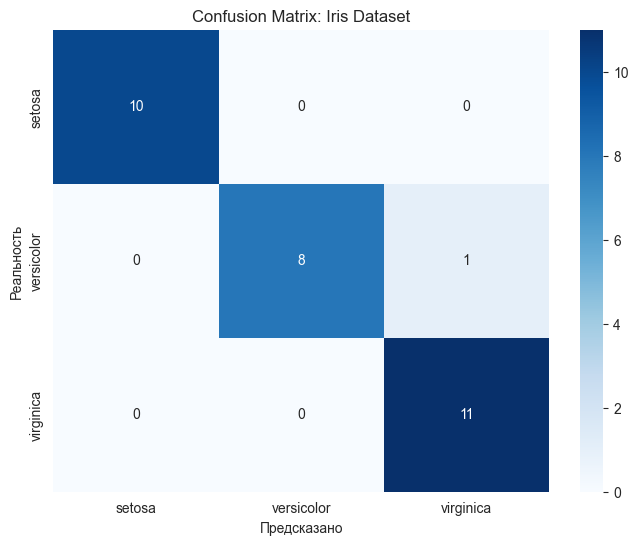

In [7]:
y_pred_test = model.predict(X_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)

plt.title('Confusion Matrix: Iris Dataset')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

In [8]:
search_space = SearchSpace(
    activations=[ReLU, Tanh, LeakyReLU],
    hidden_sizes=[8, 16, 32],
    lr_rates=[0.1, 0.05, 0.01, 0.005],
    optimizers=[Adam, SGD, MomentumSGD],
    min_layers=1,
    max_layers=3
)

config = EvolutionConfig(
    pop_size=8,
    generations=5,
    eval_epochs=10,
    survival_rate=0.5,
    migration_interval=2
)

engine = EvolutionaryEngine(
    input_dim=4,
    output_dim=3,
    loss_fn=CrossEntropy(),
    metrics=[Accuracy()],
    search_space=search_space,
    config=config,
    output_activation=Softmax
)

best_genome = engine.run(train_loader, test_loader)

print(best_genome.summary())
print(f"Лучшая точность (Val Accuracy): {best_genome.best_score:.4f}")

best_model = best_genome.build_model(CrossEntropy(), [Accuracy()], Softmax)
best_genome.load_weights(best_model)
eval_res = best_model.evaluate(test_loader)
print(f"Итоговая точность на тесте: {eval_res['accuracy']:.4f}")


--- Generation 1/5 ---
[Sniper] Val Accuracy: 0.9667 | [SGD | LR: 0.1] Arch: In -> 32(ReLU) -> Out
[Mobile] Val Accuracy: 1.0000 | [Adam | LR: 0.05] Arch: In -> 16(LeakyReLU) -> Out
[Flash] Val Accuracy: 1.0000 | [MomentumSGD | LR: 0.05] Arch: In -> 32(Tanh) -> Out

--- Generation 2/5 ---
[Sniper] Val Accuracy: 1.0000 | [Adam | LR: 0.1] Arch: In -> 32(Tanh) -> 16(LeakyReLU) -> Out
[Mobile] Val Accuracy: 1.0000 | [Adam | LR: 0.05] Arch: In -> 16(LeakyReLU) -> Out
[Flash] Val Accuracy: 1.0000 | [MomentumSGD | LR: 0.05] Arch: In -> 32(Tanh) -> Out

--- Generation 3/5 ---
[Sniper] Val Accuracy: 1.0000 | [Adam | LR: 0.1] Arch: In -> 32(Tanh) -> 16(LeakyReLU) -> Out
[Mobile] Val Accuracy: 1.0000 | [Adam | LR: 0.05] Arch: In -> 16(LeakyReLU) -> Out
[Flash] Val Accuracy: 1.0000 | [MomentumSGD | LR: 0.05] Arch: In -> 32(Tanh) -> Out

--- Generation 4/5 ---
[Sniper] Val Accuracy: 1.0000 | [Adam | LR: 0.1] Arch: In -> 32(Tanh) -> 16(LeakyReLU) -> Out
[Mobile] Val Accuracy: 1.0000 | [Adam | LR: 0

# Распознавание цифр (MNIST)

In [16]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X = mnist.data[:10_000] / 255.0
y = mnist.target[:10_000].astype(int).reshape(-1, 1)

In [17]:
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

X_train_mnist, X_test_mnist, y_train_mnist, y_test_mnist = train_test_split(X, y_onehot, test_size=0.2)

In [18]:
train_loader = DataLoader(Dataset(X_train_mnist, y_train_mnist), batch_size=32)
test_loader = DataLoader(Dataset(X_test_mnist, y_test_mnist), batch_size=32, shuffle=False)

In [19]:
mnist_net = Sequential(
    Linear(784, 64),
    ReLU(),
    Linear(64, 10),
    Softmax()
)

mnist_model = Model(
    network=mnist_net,
    loss_fn=CrossEntropy(),
    optimizer=Adam(mnist_net.parameters(), lr=0.005),
    metrics=[Accuracy()]
)

In [20]:
print("Обучение на MNIST:")
mnist_model.fit(train_loader, epochs=10, val_loader=test_loader)

Обучение на MNIST:
Epoch [1/10] - loss: 0.4478 - accuracy: 0.9261 | eval - accuracy: 0.8975 - 1.38s
Epoch [2/10] - loss: 0.1995 - accuracy: 0.9673 | eval - accuracy: 0.9335 - 1.25s
Epoch [3/10] - loss: 0.1326 - accuracy: 0.9722 | eval - accuracy: 0.9350 - 1.42s
Epoch [4/10] - loss: 0.0882 - accuracy: 0.9699 | eval - accuracy: 0.9310 - 1.38s
Epoch [5/10] - loss: 0.0626 - accuracy: 0.9874 | eval - accuracy: 0.9400 - 1.56s
Epoch [6/10] - loss: 0.0493 - accuracy: 0.9850 | eval - accuracy: 0.9390 - 1.52s
Epoch [7/10] - loss: 0.0350 - accuracy: 0.9915 | eval - accuracy: 0.9400 - 1.51s
Epoch [8/10] - loss: 0.0367 - accuracy: 0.9971 | eval - accuracy: 0.9490 - 1.52s
Epoch [9/10] - loss: 0.0231 - accuracy: 0.9900 | eval - accuracy: 0.9330 - 1.36s
Epoch [10/10] - loss: 0.0396 - accuracy: 0.9905 | eval - accuracy: 0.9435 - 1.47s


In [14]:
idx = np.random.randint(len(X_test_mnist))
sample = X_test_mnist[idx:idx+1]
pred = mnist_model.predict(sample)
print(f"\nРеальная цифра {np.argmax(y_test_mnist[idx])}, Предсказано {np.argmax(pred)}")


Реальная цифра 8, Предсказано 8


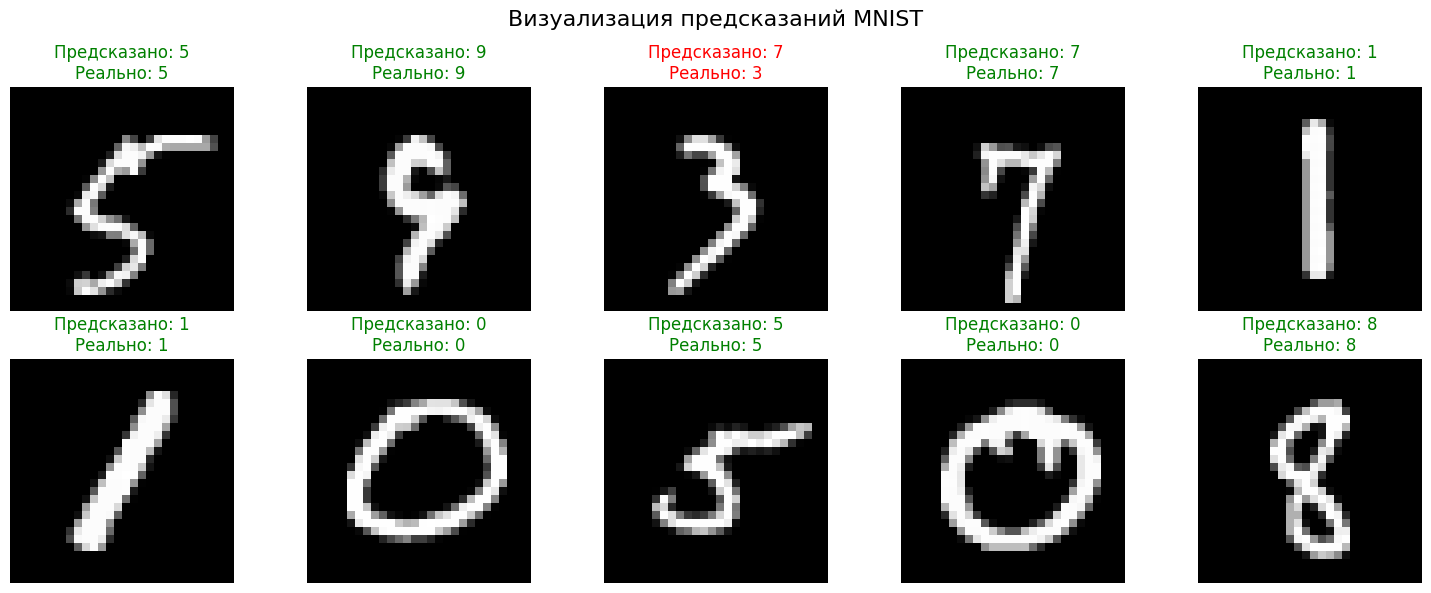

In [18]:
plt.figure(figsize=(15, 6))
plt.suptitle("Визуализация предсказаний MNIST", fontsize=16)

indices = np.random.choice(len(X_test_mnist), 10, replace=False)

for i, idx in enumerate(indices):
    img = X_test_mnist[idx].reshape(28, 28)

    probs = mnist_model.predict(X_test_mnist[idx:idx+1])
    pred = np.argmax(probs)
    true = np.argmax(y_test_mnist[idx])

    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')

    color = 'green' if pred == true else 'red'
    plt.title(f"Предсказано: {pred}\nРеально: {true}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

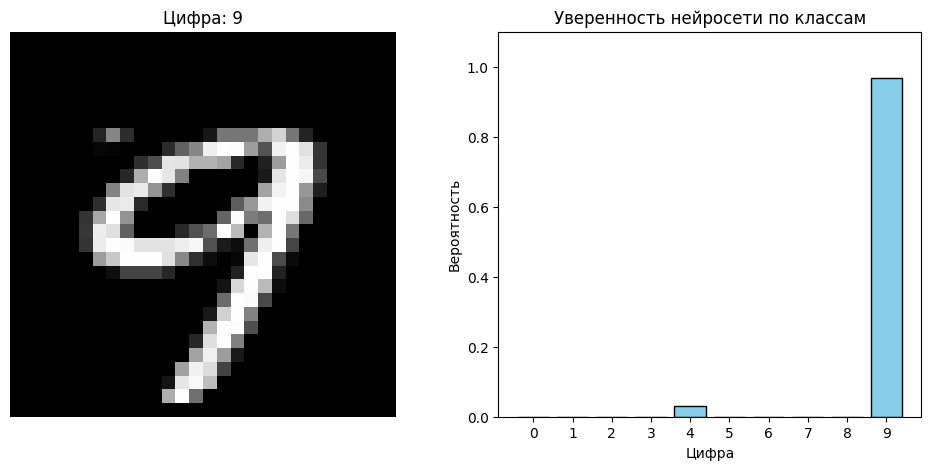

In [23]:
random_idx = np.random.randint(len(X_test_mnist))
sample_img = X_test_mnist[random_idx:random_idx + 1]
probabilities = mnist_model.predict(sample_img)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.imshow(sample_img.reshape(28, 28), cmap='gray')
ax1.set_title(f"Цифра: {np.argmax(y_test_mnist[random_idx])}")
ax1.axis('off')

ax2.bar(range(10), probabilities, color='skyblue', edgecolor='black')
ax2.set_xticks(range(10))
ax2.set_ylim(0, 1.1)
ax2.set_title("Уверенность нейросети по классам")
ax2.set_xlabel("Цифра")
ax2.set_ylabel("Вероятность")

plt.show()

In [ ]:
search_space_mnist = SearchSpace(
    activations=[ReLU, LeakyReLU],
    hidden_sizes=[32, 64, 128],
    lr_rates=[0.01, 0.001],
    optimizers=[Adam, MomentumSGD],
    min_layers=1,
    max_layers=2
)

config_mnist = EvolutionConfig(
    pop_size=4,
    generations=10,
    eval_epochs=2,
    overfit_penalty=0.1
)

engine_mnist = EvolutionaryEngine(
    input_dim=784,
    output_dim=10,
    loss_fn=CrossEntropy(),
    metrics=[Accuracy()],
    search_space=search_space_mnist,
    config=config_mnist,
    output_activation=Softmax
)

best_mnist_genome = engine_mnist.run(train_loader, test_loader)

print(best_mnist_genome.summary())
print(f"Количество параметров: {best_mnist_genome.params_count}")
print(f"Лучшая точность: {best_mnist_genome.best_score:.4f}")

best_mnist_model = best_mnist_genome.build_model(CrossEntropy(), [Accuracy()], Softmax)
best_mnist_genome.load_weights(best_mnist_model)

best_mnist_model.fit(train_loader, epochs=10, val_loader=test_loader)


--- Generation 1/10 ---
[Sniper] Val Accuracy: 0.9270 | [Adam | LR: 0.01] Arch: In -> 128(ReLU) -> 128(ReLU) -> Out
[Mobile] Val Accuracy: 0.9245 | [Adam | LR: 0.01] Arch: In -> 32(ReLU) -> Out
[Flash] Val Accuracy: 0.9360 | [Adam | LR: 0.01] Arch: In -> 64(LeakyReLU) -> Out

--- Generation 2/10 ---
[Sniper] Val Accuracy: 0.9305 | [Adam | LR: 0.01] Arch: In -> 128(ReLU) -> 32(LeakyReLU) -> Out


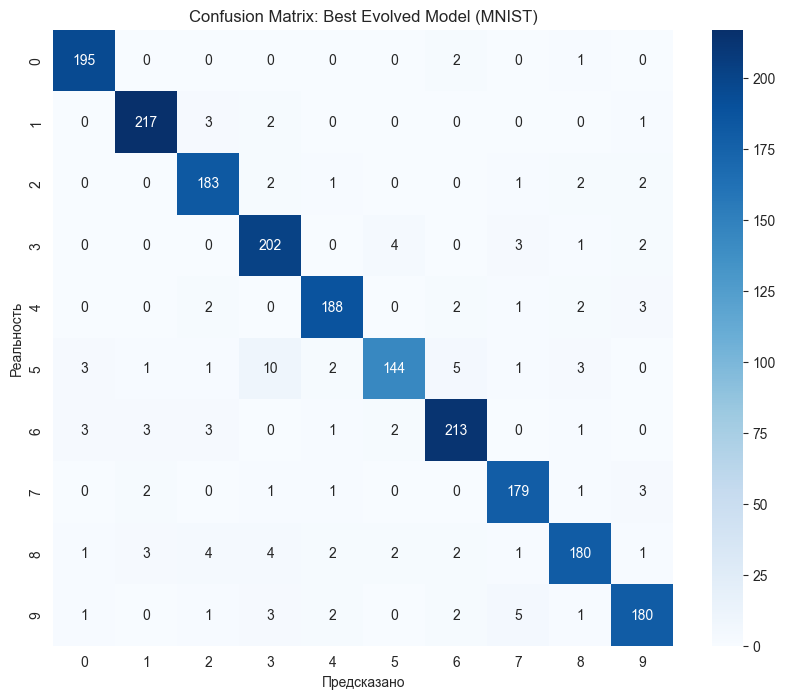

In [29]:
y_pred_probs = best_mnist_model.predict(X_test_mnist)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
y_true_labels = np.argmax(y_test_mnist, axis=1)

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Best Evolved Model (MNIST)')
plt.xlabel('Предсказано')
plt.ylabel('Реальность')
plt.show()

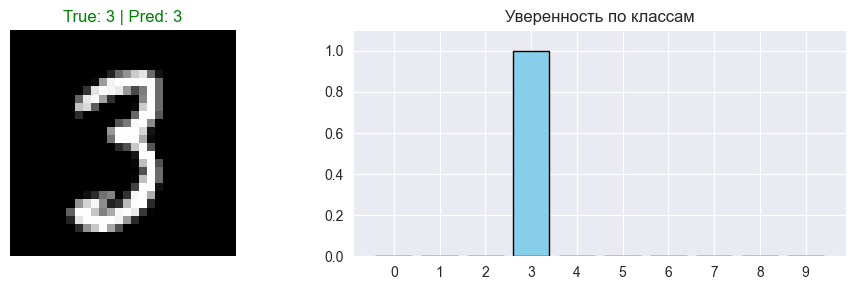

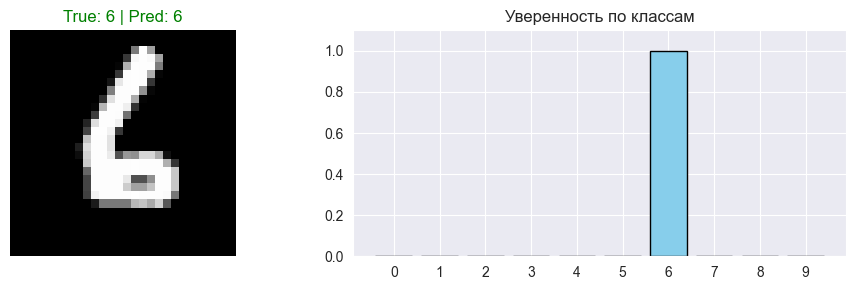

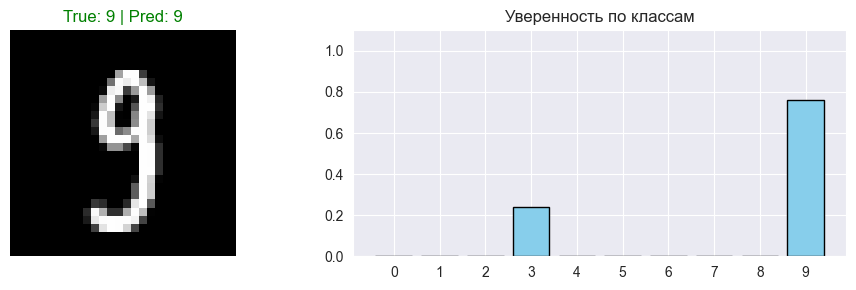

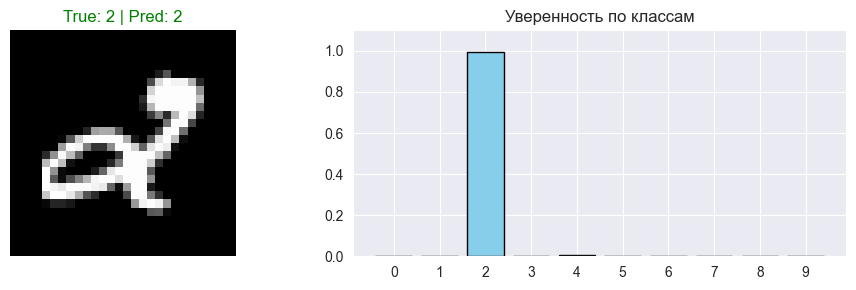

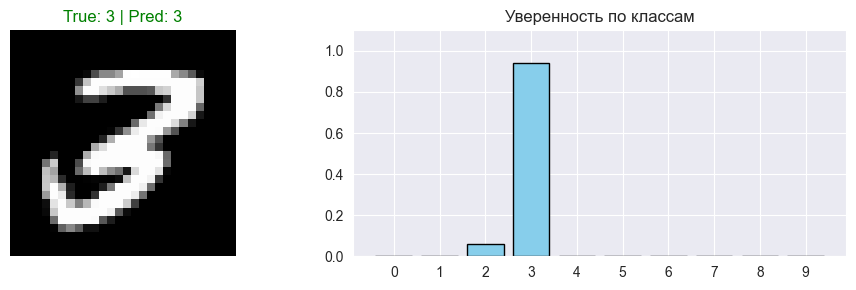


Финишная точность модели: 0.9405


In [28]:
indices = np.random.choice(len(X_test_mnist), 5, replace=False)

for idx in indices:
    sample_img = X_test_mnist[idx:idx+1]
    probs = best_mnist_model.predict(sample_img)[0]
    pred_label = np.argmax(probs)
    true_label = np.argmax(y_test_mnist[idx])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

    ax1.imshow(sample_img.reshape(28, 28), cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    ax1.set_title(f"True: {true_label} | Pred: {pred_label}", color=color)
    ax1.axis('off')

    ax2.bar(range(10), probs, color='skyblue', edgecolor='black')
    ax2.set_xticks(range(10))
    ax2.set_ylim(0, 1.1)
    ax2.set_title("Уверенность по классам")

    plt.tight_layout()
    plt.show()

final_results = best_mnist_model.evaluate(test_loader)
print(f"\nФинишная точность модели: {final_results['accuracy']:.4f}")